# Notebook 02 — Exploratory Data Analysis

**Input:** `data/raw/infra_logs.csv`

> Label isolation: `is_anomaly` is used **only** for visual highlighting in plots, never for statistics or model decisions.


In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sys.path.insert(0, os.path.join('..', 'src'))

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.float_format', '{:.2f}'.format)

df = pd.read_csv('../data/raw/infra_logs.csv', parse_dates=['timestamp'])
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head(3)


Shape: (43200, 12)
Columns: ['timestamp', 'server_id', 'service_type', 'cpu_utilization_pct', 'memory_utilization_pct', 'disk_io_mbps', 'network_latency_ms', 'response_time_ms', 'error_rate_pct', 'requests_per_min', 'is_anomaly', 'anomaly_type']


,timestamp,server_id,service_type,cpu_utilization_pct,memory_utilization_pct,disk_io_mbps,network_latency_ms,response_time_ms,error_rate_pct,requests_per_min,is_anomaly,anomaly_type
0,2024-01-01,srv-api-01,API Gateway,16.10,18.90,5.87,6.29,28.47,0.27,185.62,0,none
1,2024-01-01,srv-api-02,API Gateway,8.77,8.88,3.44,3.48,2.41,0.00,171.66,0,none
2,2024-01-01,srv-api-03,API Gateway,11.70,9.16,6.43,5.43,4.97,0.37,198.71,0,none


## 1. Time-Series Plots — 3 Sample Servers

One server per service type archetype. Red dots = injected anomalies (ground truth, shown **only** for visual sanity checking).


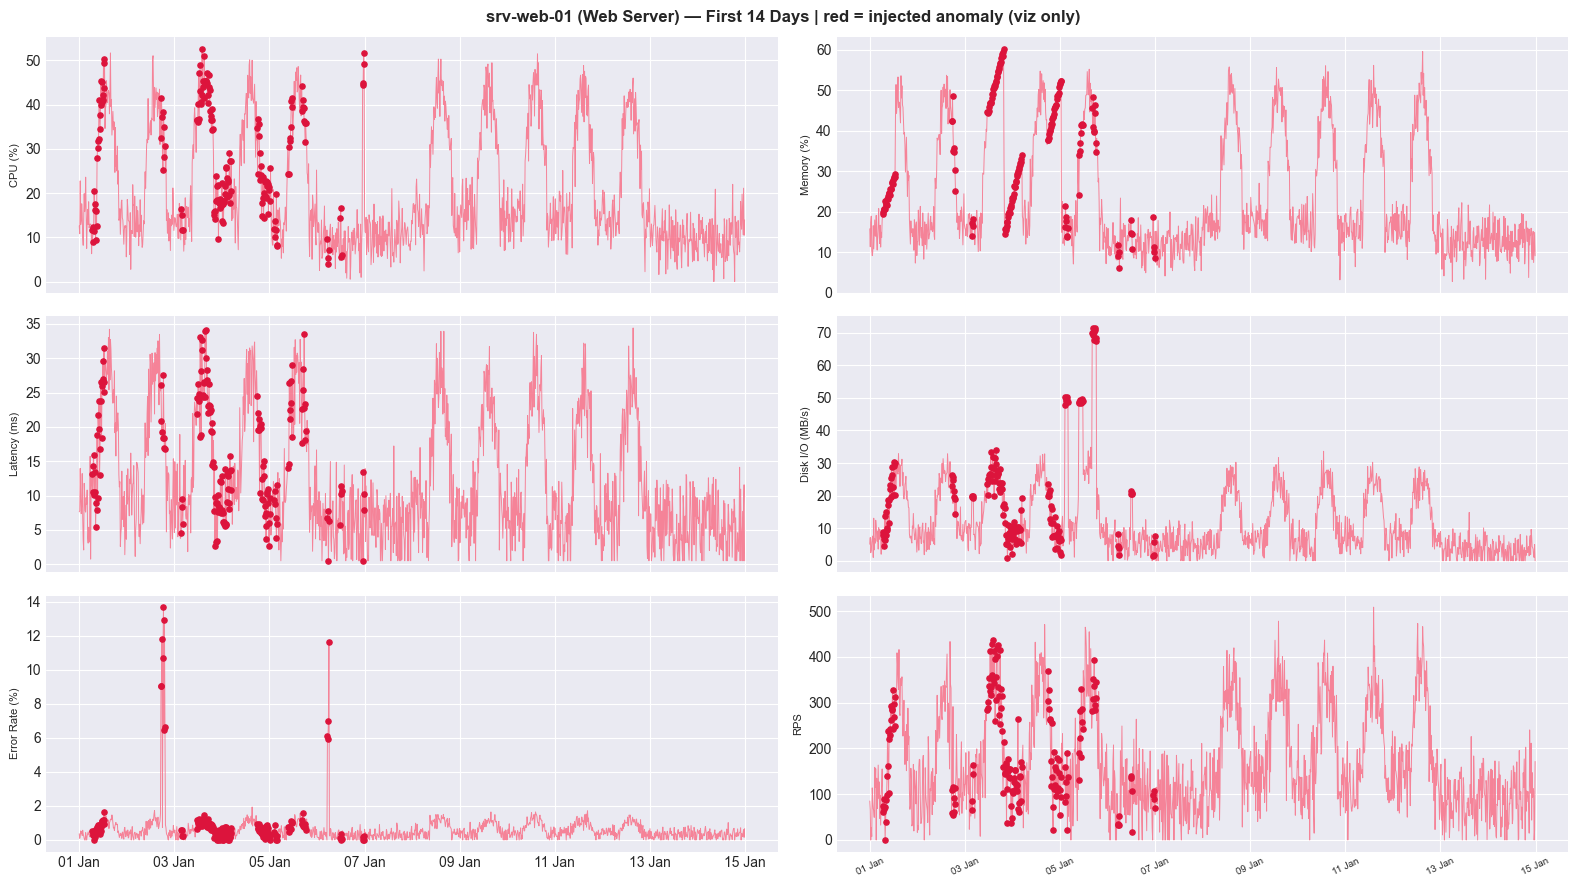

Saved eda_ts_srv-web-01.png


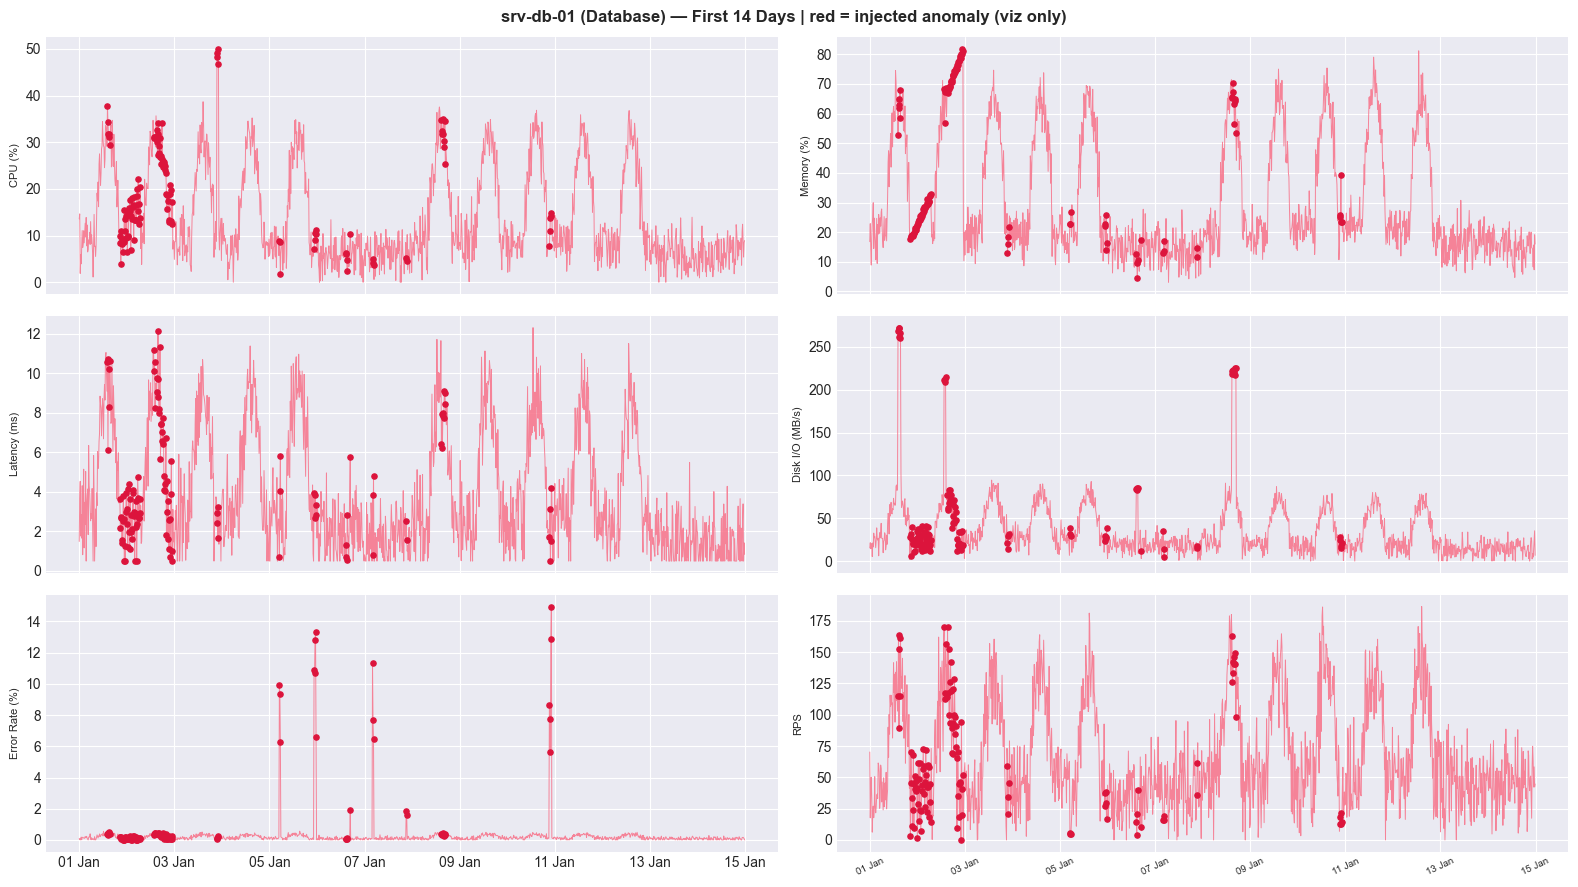

Saved eda_ts_srv-db-01.png


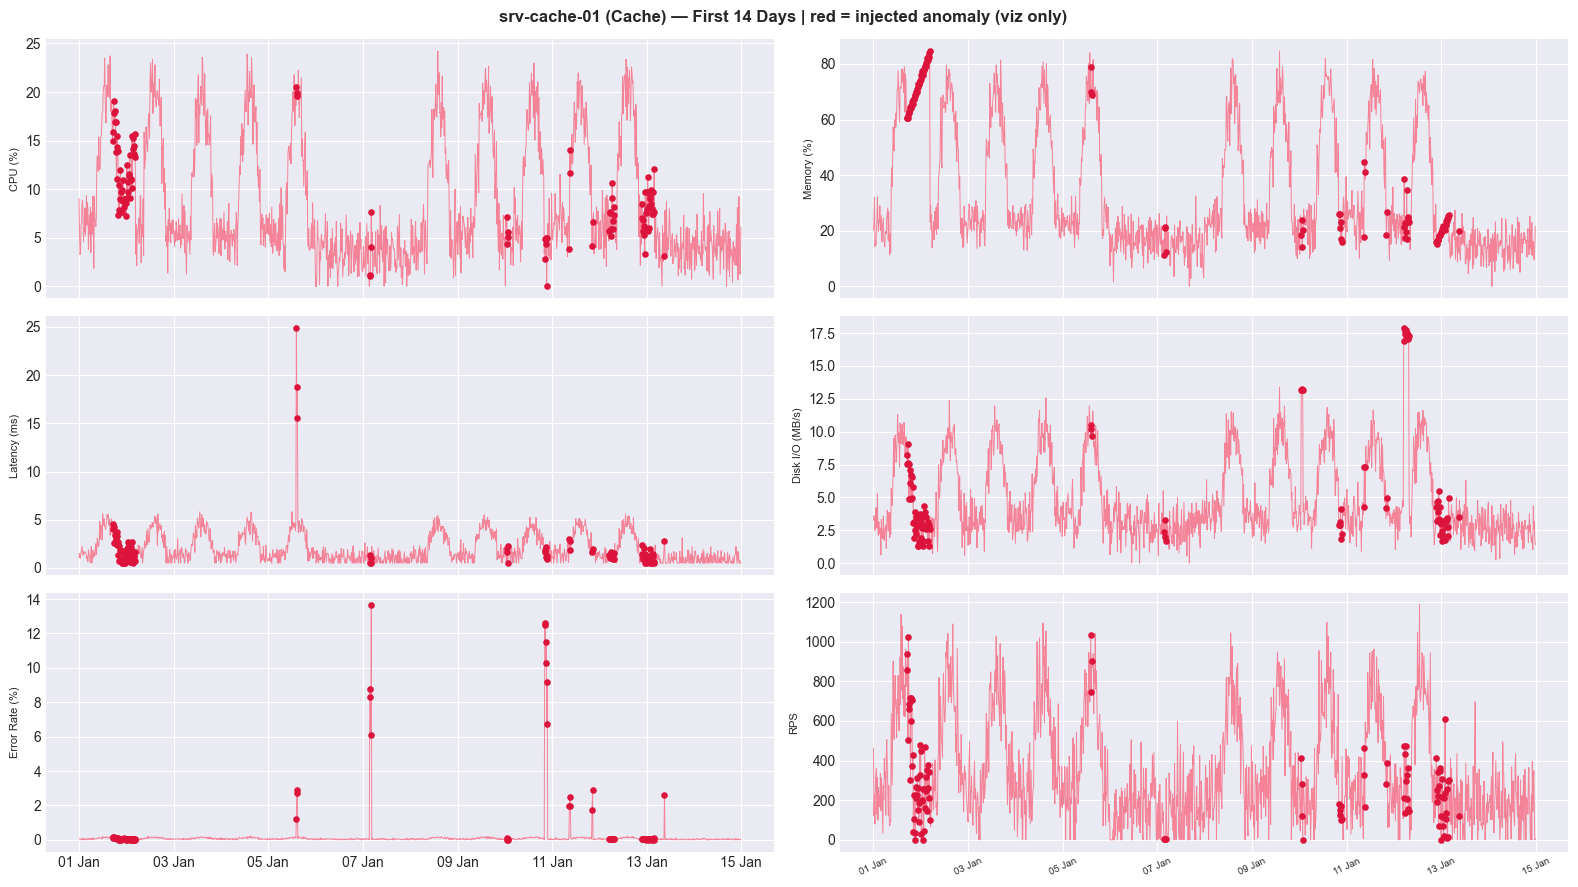

Saved eda_ts_srv-cache-01.png


In [2]:
SAMPLE_SERVERS = ['srv-web-01', 'srv-db-01', 'srv-cache-01']
METRICS = ['cpu_utilization_pct', 'memory_utilization_pct', 'network_latency_ms',
           'disk_io_mbps', 'error_rate_pct', 'requests_per_min']
MLABELS = ['CPU (%)', 'Memory (%)', 'Latency (ms)', 'Disk I/O (MB/s)', 'Error Rate (%)', 'RPS']

# Show first 14 days for readability
cutoff = df['timestamp'].min() + pd.Timedelta(days=14)

for srv in SAMPLE_SERVERS:
    sdf = df[(df['server_id'] == srv) & (df['timestamp'] < cutoff)].copy()
    svc = sdf['service_type'].iloc[0]

    fig, axes = plt.subplots(3, 2, figsize=(16, 9), sharex=True)
    fig.suptitle(f'{srv} ({svc}) — First 14 Days | red = injected anomaly (viz only)',
                 fontsize=12, fontweight='bold')
    axes = axes.flatten()

    for ax, metric, label in zip(axes, METRICS, MLABELS):
        ax.plot(sdf['timestamp'], sdf[metric], lw=0.7, alpha=0.85)
        anom = sdf[sdf['is_anomaly'] == 1]
        ax.scatter(anom['timestamp'], anom[metric], color='crimson', s=14, zorder=5)
        ax.set_ylabel(label, fontsize=8)

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    plt.xticks(rotation=25, fontsize=7)
    plt.tight_layout()
    plt.savefig(f'../results/eda_ts_{srv}.png', dpi=110, bbox_inches='tight')
    plt.show()
    print(f'Saved eda_ts_{srv}.png')


## 2. Diurnal Pattern Check

Average CPU and requests_per_min by hour-of-day across all servers and days.
A clear business-hours peak (9–19) confirms the synthetic generation is realistic.


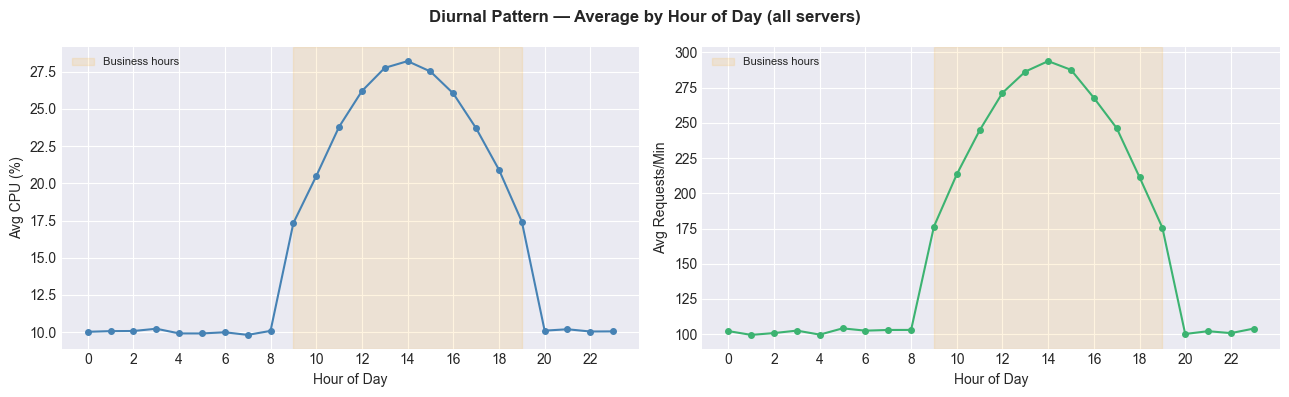

Peak CPU (business hrs):  28.2%
Trough CPU (off-hours):   9.8%
Peak-to-trough ratio:     2.87x


In [3]:
df['hour'] = df['timestamp'].dt.hour
diurnal = df.groupby('hour')[['cpu_utilization_pct', 'requests_per_min']].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Diurnal Pattern — Average by Hour of Day (all servers)', fontsize=12, fontweight='bold')

ax1.plot(diurnal.index, diurnal['cpu_utilization_pct'], marker='o', ms=4, color='steelblue')
ax1.axvspan(9, 19, alpha=0.12, color='orange', label='Business hours')
ax1.set_xlabel('Hour of Day'); ax1.set_ylabel('Avg CPU (%)')
ax1.set_xticks(range(0, 24, 2)); ax1.legend(fontsize=8)

ax2.plot(diurnal.index, diurnal['requests_per_min'], marker='o', ms=4, color='mediumseagreen')
ax2.axvspan(9, 19, alpha=0.12, color='orange', label='Business hours')
ax2.set_xlabel('Hour of Day'); ax2.set_ylabel('Avg Requests/Min')
ax2.set_xticks(range(0, 24, 2)); ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../results/eda_diurnal.png', dpi=110, bbox_inches='tight')
plt.show()

peak_cpu   = diurnal['cpu_utilization_pct'].max()
trough_cpu = diurnal['cpu_utilization_pct'].min()
print(f'Peak CPU (business hrs):  {peak_cpu:.1f}%')
print(f'Trough CPU (off-hours):   {trough_cpu:.1f}%')
print(f'Peak-to-trough ratio:     {peak_cpu/trough_cpu:.2f}x')


## 3. Weekend vs Weekday Comparison


In [4]:
df['day_type'] = df['timestamp'].dt.dayofweek.apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

day_summary = df.groupby('day_type')[['cpu_utilization_pct', 'requests_per_min',
                                       'network_latency_ms']].mean().round(2)
print('Average metrics by day type:')
print(day_summary)


Average metrics by day type:
          cpu_utilization_pct  requests_per_min  network_latency_ms
day_type                                                           
Weekday                 19.30            198.32               11.48
Weekend                  7.85             79.48                4.21


## 4. Correlation Heatmap

High correlations between CPU, memory, latency, and response_time **justify using PCA** — 
these features are not independent, so PCA can compress them efficiently without losing the 
cross-metric anomaly signal.


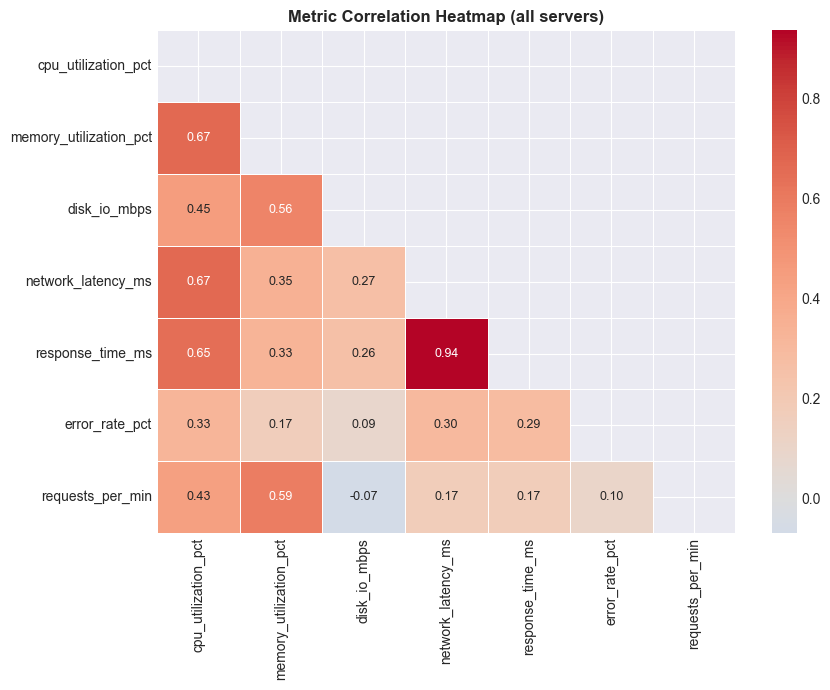

In [5]:
NUMERIC_COLS = ['cpu_utilization_pct', 'memory_utilization_pct', 'disk_io_mbps',
                'network_latency_ms', 'response_time_ms', 'error_rate_pct', 'requests_per_min']

corr = df[NUMERIC_COLS].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Metric Correlation Heatmap (all servers)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/eda_correlation.png', dpi=110, bbox_inches='tight')
plt.show()


## 5. Per-Service-Type Baseline Distribution

Box plots confirm that each service type has a different baseline —
this **justifies per-server z-score normalization** rather than global normalization.


C:\Users\Pyramid\AppData\Local\Temp\ipykernel_21860\1727757821.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=normal_df, x='service_type', y=metric, ax=ax, palette='husl')
C:\Users\Pyramid\AppData\Local\Temp\ipykernel_21860\1727757821.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15, fontsize=7)
C:\Users\Pyramid\AppData\Local\Temp\ipykernel_21860\1727757821.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=normal_df, x='service_type', y=metric, ax=ax, palette='husl')
C:\Users\Pyramid\AppData\Local\Temp\ipykernel_21860\1727757821.py:12

C:\Users\Pyramid\AppData\Local\Temp\ipykernel_21860\1727757821.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=normal_df, x='service_type', y=metric, ax=ax, palette='husl')
C:\Users\Pyramid\AppData\Local\Temp\ipykernel_21860\1727757821.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15, fontsize=7)
C:\Users\Pyramid\AppData\Local\Temp\ipykernel_21860\1727757821.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=normal_df, x='service_type', y=metric, ax=ax, palette='husl')
C:\Users\Pyramid\AppData\Local\Temp\ipykernel_21860\1727757821.py:12

C:\Users\Pyramid\AppData\Local\Temp\ipykernel_21860\1727757821.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=normal_df, x='service_type', y=metric, ax=ax, palette='husl')
C:\Users\Pyramid\AppData\Local\Temp\ipykernel_21860\1727757821.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15, fontsize=7)
C:\Users\Pyramid\AppData\Local\Temp\ipykernel_21860\1727757821.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=normal_df, x='service_type', y=metric, ax=ax, palette='husl')


C:\Users\Pyramid\AppData\Local\Temp\ipykernel_21860\1727757821.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15, fontsize=7)


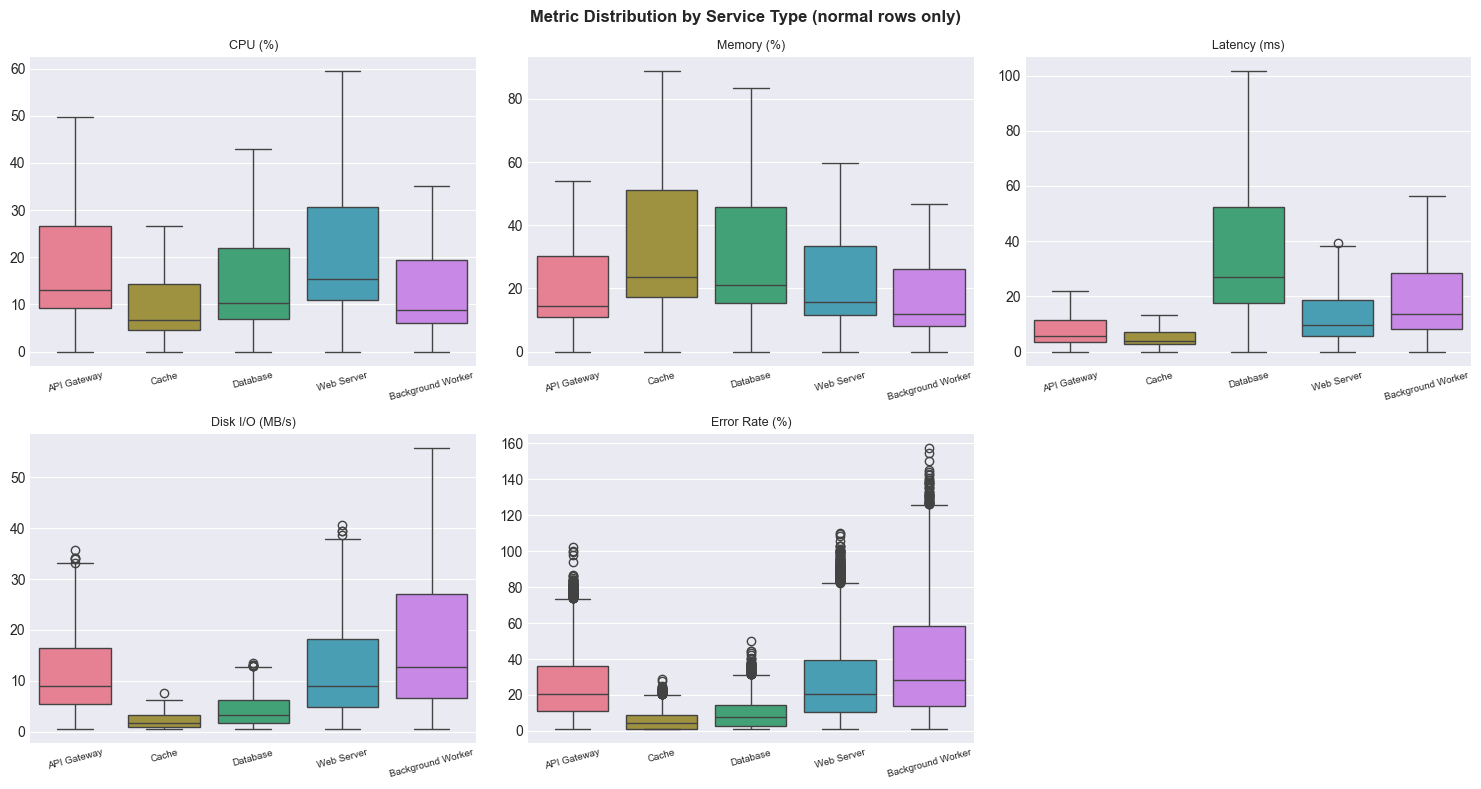

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Metric Distribution by Service Type (normal rows only)', fontsize=12, fontweight='bold')
axes = axes.flatten()

# Use only normal rows to show true baseline distributions
normal_df = df[df['is_anomaly'] == 0]

for ax, metric, label in zip(axes, NUMERIC_COLS[:6], MLABELS[:6]):
    sns.boxplot(data=normal_df, x='service_type', y=metric, ax=ax, palette='husl')
    ax.set_title(label, fontsize=9)
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, fontsize=7)
    ax.set_ylabel('')

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('../results/eda_service_distributions.png', dpi=110, bbox_inches='tight')
plt.show()


## 6. Anomaly Type Distribution


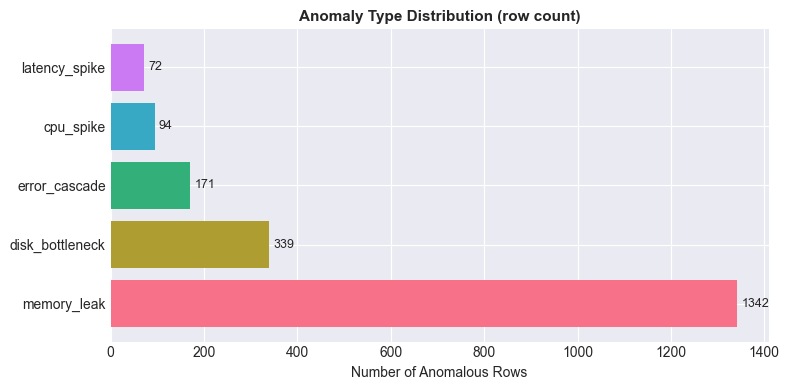


Row counts per anomaly type:
                 rows
anomaly_type         
memory_leak      1342
disk_bottleneck   339
error_cascade     171
cpu_spike          94
latency_spike      72

Note: memory_leak has highest row count because each event spans 6-12 hours.
cpu_spike and latency_spike have lowest count (15-60 min events).


In [7]:
anom_dist = df[df['is_anomaly'] == 1]['anomaly_type'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(anom_dist.index, anom_dist.values, color=sns.color_palette('husl', len(anom_dist)))
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel('Number of Anomalous Rows')
ax.set_title('Anomaly Type Distribution (row count)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/eda_anomaly_dist.png', dpi=110, bbox_inches='tight')
plt.show()

print('\nRow counts per anomaly type:')
print(anom_dist.to_frame('rows'))
print('\nNote: memory_leak has highest row count because each event spans 6-12 hours.')
print('cpu_spike and latency_spike have lowest count (15-60 min events).')


## 7. Anomaly Metric Signatures — Anomaly vs Normal Means

Shows which metrics deviate from normal for each anomaly type.


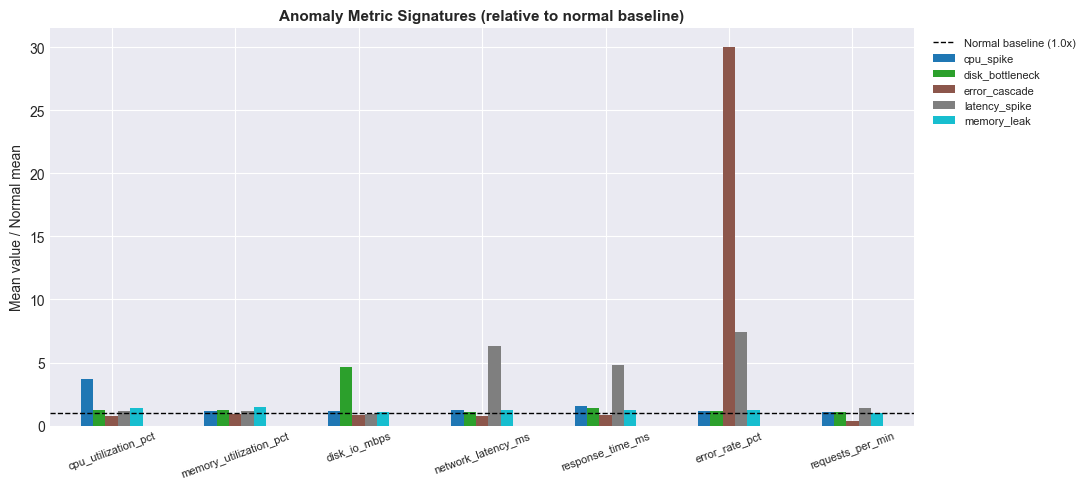

In [8]:
sig = df.groupby('anomaly_type')[NUMERIC_COLS].mean().T
# Normalise each metric to its 'none' (normal) value to show relative deviation
sig_rel = sig.div(sig['none'], axis=0).drop(columns='none')

fig, ax = plt.subplots(figsize=(11, 5))
sig_rel.plot(kind='bar', ax=ax, colormap='tab10')
ax.axhline(1.0, color='black', lw=1, ls='--', label='Normal baseline (1.0x)')
ax.set_ylabel('Mean value / Normal mean')
ax.set_title('Anomaly Metric Signatures (relative to normal baseline)', fontsize=11, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, fontsize=8)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('../results/eda_anomaly_signatures.png', dpi=110, bbox_inches='tight')
plt.show()


## 8. EDA Insights Summary

**Insight 1 — Diurnal pattern confirmed:** CPU and request volume are ~2–3x higher during
business hours (9–19) than overnight, and further reduced on weekends. Any anomaly detection
method that ignores time-of-day context will have high false positives at peak hours.

**Insight 2 — Cross-metric correlations justify PCA:** `network_latency_ms` and
`response_time_ms` are strongly correlated (expected — response time = latency + processing).
CPU/memory also correlate. PCA will efficiently compress these correlated dimensions without
losing the multi-metric anomaly signal.

**Insight 3 — Per-service-type baselines are heterogeneous:** Database servers run
substantially higher disk I/O and memory than Cache servers. Global z-score normalization
would flag normal Database memory as anomalous. **Per-server normalization is mandatory.**

**Insight 4 — Anomaly duration varies significantly:** `memory_leak` rows dominate the count
because each event spans 6–12 hours (24–48 readings). `cpu_spike` and `latency_spike` are
point anomalies (1–3 readings). This asymmetry means methods that score individual points
(Isolation Forest) may behave differently from methods that score clusters (K-Means).

**Insight 5 — Anomaly signatures are multi-metric, not single-metric:** The signature plot
shows that each anomaly type affects 2–3 metrics simultaneously (e.g. error_cascade:
error_rate up AND requests_per_min down). Single-metric thresholds would miss most of these.
This is exactly why PCA + clustering is the right tool.


In [9]:
print('EDA complete. Plots saved to results/')
print('Next: Run 03_feature_engineering.ipynb')


EDA complete. Plots saved to results/
Next: Run 03_feature_engineering.ipynb
